# Hamiltonian Simulation Case Study

## Problem

Use `quantum-backend-bench` to study how a first-order Trotterized Ising-style Hamiltonian simulation scales as the number of qubits and Trotter steps change.

The benchmark implements:

`H = sum_i Z_i Z_{i+1} + 0.5 * sum_i X_i`

## Quantum Advantage

None is claimed in this notebook. These are small local simulator runs intended to make benchmark structure, runtime, and reproducibility visible. The same workflow can be scaled cautiously for larger local studies.

## SDK Advantages

- Cirq gives a fast, credential-free first path for local circuit simulation.
- Qiskit Aer is useful when users want a common local simulator workflow that includes transpilation-style overhead in this package's adapter timing.
- QuTiP is useful for small physics-oriented statevector-style simulation coverage.

## Variables

- `case_grid`: Hamiltonian simulation cases to run.
- `active_backends`: installed local backends used for the case study.
- `shots`: measurement samples per run.
- `repeats`: repeated executions for runtime samples.
- `time`: evolution time parameter.
- `trotter_steps`: first-order Trotter step count.


In [1]:
import importlib.util
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from quantum_backend_bench.benchmarks.hamiltonian_sim import build_benchmark
from quantum_backend_bench.core.runner import run_benchmark
from quantum_backend_bench import results_to_dataframe
from quantum_backend_bench.utils.formatting import format_results_table
from quantum_backend_bench.utils.io import save_csv, save_json

ARTIFACT_DIR = Path("../artifacts/notebooks")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)


def ket(state):
    return f"|{state}>"


candidate_backends = {
    "cirq": ["cirq"],
    "qiskit_aer": ["qiskit", "qiskit_aer"],
    "qutip": ["qutip"],
}
active_backends = [
    backend
    for backend, modules in candidate_backends.items()
    if all(importlib.util.find_spec(module) is not None for module in modules)
]

shots = 256
repeats = 2
case_grid = [
    {"n_qubits": 3, "time": 0.5, "trotter_steps": 1},
    {"n_qubits": 3, "time": 0.5, "trotter_steps": 2},
    {"n_qubits": 4, "time": 0.5, "trotter_steps": 1},
    {"n_qubits": 4, "time": 1.0, "trotter_steps": 2},
]

print("Active local backends:", ", ".join(active_backends) if active_backends else "none")

Active local backends: cirq, qiskit_aer, qutip


## Run the Case Grid

Each case uses the same package benchmark builder. The result dictionaries include runtime samples, structural metrics, measurement counts, and backend caveats.


In [2]:
if not active_backends:
    raise RuntimeError(
        "No local execution backend is installed. Install at least quantum-backend-bench[cirq]."
    )

results = []
for case in case_grid:
    benchmark = build_benchmark(**case)
    results.extend(run_benchmark(benchmark, active_backends, shots=shots, repeats=repeats))

print(format_results_table(results))

frame = results_to_dataframe(results)
columns = [
    "case_label",
    "backend",
    "n_qubits",
    "runtime_seconds",
    "runtime_seconds_stddev",
    "depth",
    "gate_count",
    "two_qubit_gate_count",
]
display_frame = frame[columns].copy()
for column in ["runtime_seconds", "runtime_seconds_stddev"]:
    display_frame[column] = display_frame[column].round(6)
display_frame

case                | backend    | runtime_seconds | runtime_stddev | depth | gate_count | two_qubit_gate_count | success_prob
--------------------+------------+-----------------+----------------+-------+------------+----------------------+-------------
hamiltonian_sim n=3 | cirq       | 0.004714        | 0.001439       | 8     | 9          | 4                    | None        
hamiltonian_sim n=3 | qiskit_aer | 0.210676        | 0.000720       | 8     | 9          | 4                    | None        
hamiltonian_sim n=3 | qutip      | 0.000814        | 0.000406       | 8     | 9          | 4                    | None        
hamiltonian_sim n=3 | cirq       | 0.009714        | 0.001105       | 15    | 18         | 8                    | None        
hamiltonian_sim n=3 | qiskit_aer | 0.169755        | 0.024860       | 15    | 18         | 8                    | None        
hamiltonian_sim n=3 | qutip      | 0.001611        | 0.000152       | 15    | 18         | 8                   

,case_label,backend,n_qubits,runtime_seconds,runtime_seconds_stddev,depth,gate_count,two_qubit_gate_count
0,hamiltonian_sim n=3,cirq,3,0.004714,0.001439,8,9,4
1,hamiltonian_sim n=3,qiskit_aer,3,0.210676,0.000720,8,9,4
2,hamiltonian_sim n=3,qutip,3,0.000814,0.000406,8,9,4
3,hamiltonian_sim n=3,cirq,3,0.009714,0.001105,15,18,8
4,hamiltonian_sim n=3,qiskit_aer,3,0.169755,0.024860,15,18,8
5,hamiltonian_sim n=3,qutip,3,0.001611,0.000152,15,18,8
6,hamiltonian_sim n=4,cirq,4,0.009608,0.000607,11,13,6
7,hamiltonian_sim n=4,qiskit_aer,4,0.169987,0.005955,11,13,6
8,hamiltonian_sim n=4,qutip,4,0.003467,0.002867,11,13,6
9,hamiltonian_sim n=4,cirq,4,0.012173,0.002108,18,26,12


## Runtime Scaling

Runtime is local-machine dependent, but this view helps users see how each SDK adapter responds to larger Trotterized circuits in the same environment.


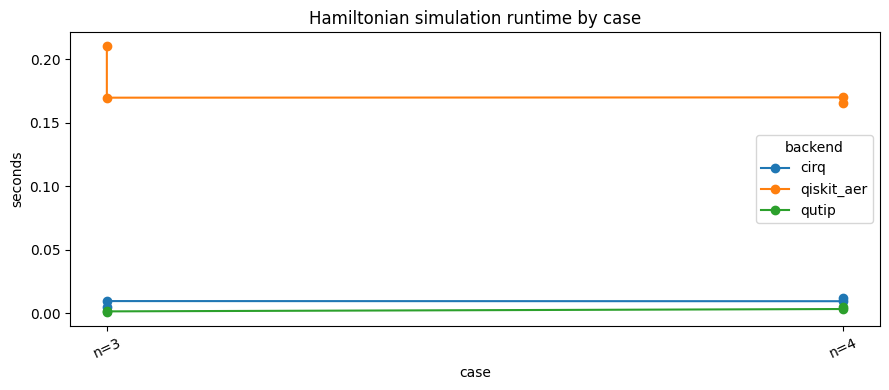

In [3]:
plot_frame = display_frame.copy()
plot_frame["case"] = plot_frame["case_label"].str.replace("hamiltonian_sim ", "", regex=False)

fig, ax = plt.subplots(figsize=(9, 4))
for backend, group in plot_frame.groupby("backend"):
    ax.plot(group["case"], group["runtime_seconds"], marker="o", label=backend)
ax.set_title("Hamiltonian simulation runtime by case")
ax.set_xlabel("case")
ax.set_ylabel("seconds")
ax.tick_params(axis="x", rotation=25)
ax.legend(title="backend")
plt.tight_layout()
plt.show()

## Circuit Structure

Depth and gate counts reflect the Trotterized circuit construction. Increasing `trotter_steps` should increase circuit depth and gate count.


In [4]:
structure = (
    frame[["case_label", "n_qubits", "depth", "gate_count", "two_qubit_gate_count"]]
    .drop_duplicates()
    .sort_values(["n_qubits", "case_label"])
)
structure

,case_label,n_qubits,depth,gate_count,two_qubit_gate_count
0,hamiltonian_sim n=3,3,8,9,4
3,hamiltonian_sim n=3,3,15,18,8
6,hamiltonian_sim n=4,4,11,13,6
9,hamiltonian_sim n=4,4,18,26,12


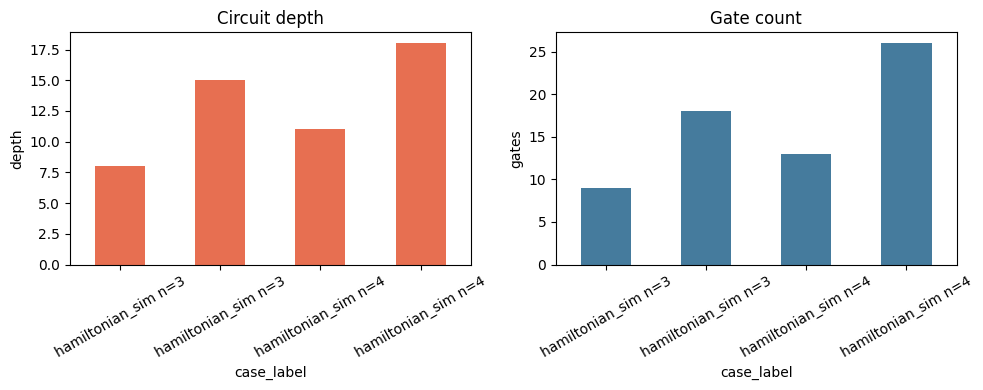

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
structure.plot(x="case_label", y="depth", kind="bar", ax=axes[0], color="#e76f51", legend=False)
axes[0].set_title("Circuit depth")
axes[0].set_ylabel("depth")
axes[0].tick_params(axis="x", rotation=30)
structure.plot(
    x="case_label", y="gate_count", kind="bar", ax=axes[1], color="#457b9d", legend=False
)
axes[1].set_title("Gate count")
axes[1].set_ylabel("gates")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

## Example Output Distribution

The next table shows the top measured states for one selected case/backend. States are ordered numerically and displayed in ket notation.


In [6]:
selected = results[0]
distribution = selected["metrics"]["measurement_distribution"]
top_states = sorted(distribution, key=lambda state: distribution[state], reverse=True)[:8]
top_states = sorted(top_states, key=lambda state: int(state, 2))
state_table = pd.DataFrame(
    [{"state": ket(state), "probability": round(distribution[state], 6)} for state in top_states]
)
print(f"Selected case: {selected['metadata']['case_label']} / {selected['backend']}")
state_table

Selected case: hamiltonian_sim n=3 / cirq


,state,probability
0,|000>,0.847656
1,|001>,0.042969
2,|010>,0.042969
3,|100>,0.058594
4,|101>,0.001953
5,|110>,0.005859


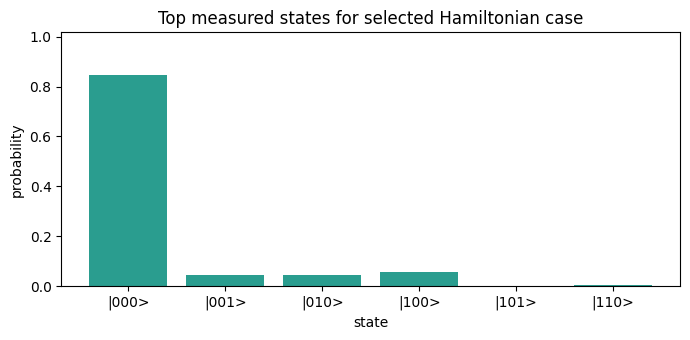

In [7]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(state_table["state"], state_table["probability"], color="#2a9d8f")
ax.set_title("Top measured states for selected Hamiltonian case")
ax.set_xlabel("state")
ax.set_ylabel("probability")
ax.set_ylim(0, max(0.05, state_table["probability"].max() * 1.2))
plt.tight_layout()
plt.show()

## Save Reproducible Artifacts


In [8]:
json_path = save_json(results, ARTIFACT_DIR / "hamiltonian_case_study.json")
csv_path = save_csv(results, ARTIFACT_DIR / "hamiltonian_case_study.csv")
print(f"Saved JSON: {json_path}")
print(f"Saved CSV: {csv_path}")

Saved JSON: ../artifacts/notebooks/hamiltonian_case_study.json
Saved CSV: ../artifacts/notebooks/hamiltonian_case_study.csv


## Verification

These checks confirm that every run produced the expected total shot count, each result has the requested runtime samples, and increasing Trotter steps increased structural cost for the three-qubit cases.


In [9]:
checks = []
for result in results:
    checks.append(
        {
            "check": f"{result['metadata']['case_label']} / {result['backend']} total shots",
            "value": sum(result["counts"].values()),
            "expected": shots * repeats,
            "passed": sum(result["counts"].values()) == shots * repeats,
        }
    )
    checks.append(
        {
            "check": f"{result['metadata']['case_label']} / {result['backend']} runtime samples",
            "value": len(result["metadata"]["runtime_seconds_samples"]),
            "expected": repeats,
            "passed": len(result["metadata"]["runtime_seconds_samples"]) == repeats,
        }
    )

three_qubit = structure[structure["n_qubits"] == 3].sort_values("depth")
checks.append(
    {
        "check": "3-qubit depth increases with more Trotter steps",
        "value": " < ".join(str(value) for value in three_qubit["depth"]),
        "expected": "monotonic increase",
        "passed": three_qubit["depth"].is_monotonic_increasing
        and three_qubit["depth"].nunique() > 1,
    }
)

verification = pd.DataFrame(checks)
verification

,check,value,expected,passed
0,hamiltonian_sim n=3 / cirq total shots,512,512,True
1,hamiltonian_sim n=3 / cirq runtime samples,2,2,True
2,hamiltonian_sim n=3 / qiskit_aer total shots,512,512,True
3,hamiltonian_sim n=3 / qiskit_aer runtime samples,2,2,True
4,hamiltonian_sim n=3 / qutip total shots,512,512,True
5,hamiltonian_sim n=3 / qutip runtime samples,2,2,True
6,hamiltonian_sim n=3 / cirq total shots,512,512,True
7,hamiltonian_sim n=3 / cirq runtime samples,2,2,True
8,hamiltonian_sim n=3 / qiskit_aer total shots,512,512,True
9,hamiltonian_sim n=3 / qiskit_aer runtime samples,2,2,True
